<a href="https://colab.research.google.com/github/pedroyoshikadogarcia/Checkpoint-01-An-lise-de-Dados-de-Energia-SERS-02-2026/blob/main/CP1_SERS_2_Semestre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Grupo:
Gabriel dos Santos Siqueira RM: 572200

Pedro Andreassa Zamai RM: 569318

Pedro Yoshikado Garcia RM: 570449

Rafael Ferreirinha Quaresma RM: 571949

Thiago Maluf Hofmann RM:569852

## Dataset Escolhido:
Dataset 1 — Appliances Energy Prediction (UCI)



## Etapa A — Orange Data Mining

# Dataset

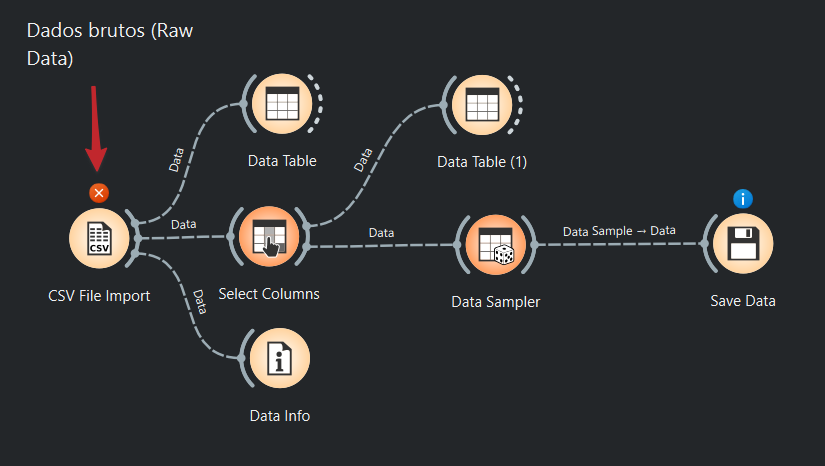

## Etapa B — Python / Pandas

In [ ]:
# Importação da biblioteca pandas, que é a ferramenta em python para manipulação, filtragem e análise de dados
import pandas as pd

## 1. Carregamento e inspeção inicial da amostra
Carregar a amostra exportada do Orange e apresentar head(), shape, info() e describe().

In [ ]:
# Carregando o arquivo CSV exportado do Orange, armazenando os dados.
dados = pd.read_csv('/content/energydata_complete.csv')

In [ ]:
# Exibindo os 5 primeiros registros do dataset para inspecionar a estrrutura inicial das colunas.
dados.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [ ]:
# Verificando as dimensoes do conjunto (quantidade, linhas/registros e colunas/atributos)
print(f'O número de registros do dataframe é: {dados.shape[0]}')
print(f'O número de atributos do dataframe é: {dados.shape[1]}')

O número de registros do dataframe é: 1974
O número de atributos do dataframe é: 8


In [ ]:
# Usando .info() para confirmar os tipos de dados e garantir que nao existem valores ausentes.
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   RH_1        1974 non-null   float64
 4   T2          1974 non-null   float64
 5   RH_2        1974 non-null   float64
 6   T3          1974 non-null   float64
 7   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


In [ ]:
# Gerando o resumo das estatisticas do dataset para entender a distruibuição dos dados de consumo e das variaveis ambientais
dados.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,20.293635,40.411386,22.231615,39.209733
std,93.826149,7.937076,1.574883,3.971923,2.126958,4.037686,1.957275,3.288818
min,20.000000,0.000000,16.790000,27.733300,16.100000,24.063300,17.200000,30.133300
25%,50.000000,0.000000,20.700000,37.205825,18.790000,37.760000,20.700000,36.900000
50%,60.000000,0.000000,21.600000,39.590000,20.000000,40.433300,22.100000,38.433300
75%,100.000000,0.000000,22.600000,42.991675,21.500000,43.228325,23.290000,41.741250
max,770.000000,50.000000,26.260000,57.496700,28.917500,56.026700,29.198600,49.226700


## 2. Renomeação de colunas
Renomear Appliances para Consumo_Eletrodomesticos e simplificar o nome de pelo menos três atributos ambientais (umidade)

In [ ]:
# Renomeando os nomes das variáveis para facilitar a leitura.
dados = dados.rename(columns={'Appliances' : 'Consumo_Eletrodomesticos',
                              'RH_1' : 'Umidade_Comodo_1',
                              'RH_2' : 'Umidade_Comodo_2',
                              'RH_3' : 'Umidade_Comodo_3'})

dados.head()

,Consumo_Eletrodomesticos,lights,T1,Umidade_Comodo_1,T2,Umidade_Comodo_2,T3,Umidade_Comodo_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


## 3. Consumo máximo registrado
Determinar o maior consumo de eletrodomésticos registrado na amostra.

In [ ]:
# Identificando o pico máximo de consumo de eletrodomésticos registrado atraves do metodo .max()
maximo = dados['Consumo_Eletrodomesticos'].max()
maximo

770

## 4. Limiar de 70% e filtro de alto consumo
Calcular o limiar correspondente a 70% do valor máximo e criar um DataFrame contendo somente os registros acima desse limite.

In [ ]:
# Calculando o limite correspondente a 70% do consumo máximo e criando df_alto contendo apenas os picos de consumo
PMAX = dados['Consumo_Eletrodomesticos'].max()
P70 = 0.70 * PMAX
df_alto = dados[dados['Consumo_Eletrodomesticos'] > P70]
df_alto

,Consumo_Eletrodomesticos,lights,T1,Umidade_Comodo_1,T2,Umidade_Comodo_2,T3,Umidade_Comodo_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.7300,38.8633
427,650,0,20.8900,36.7000,18.2900,39.6633,21.2000,36.0000
453,560,30,21.3567,36.0900,19.5667,37.1633,21.6333,35.0300
616,570,10,24.8900,32.6667,23.5600,31.1400,23.6000,30.8233
696,590,30,19.8567,47.6633,18.7000,34.1000,18.4267,37.8333
744,740,20,19.5000,42.1333,18.2600,39.1967,19.8900,39.1933
916,750,30,22.4300,43.0000,21.9267,40.1333,21.2300,42.5967
993,690,10,22.5333,45.0267,22.0667,39.7900,22.3900,41.9300
1026,560,0,21.0000,38.9000,19.2900,40.2000,21.7000,37.2000
1173,580,0,21.6000,34.6267,19.5000,33.7600,22.5750,34.8725


## 5. Contagem e percentual dos registros de alto consumo
Contar os registros selecionados e calcular qual percentual da amostra eles representam.

In [ ]:
# Contando a quantidade de registros do DataFrame df_alto e calculando a proporção que o grupo representa
qtd_alto = len(df_alto)
qtd_total = len(dados)
percentual = (qtd_alto / qtd_total) * 100
print(f"Percentual: {percentual:.2f}%")

Percentual: 1.11%


## 6. Temperatura média (T1) e filtro combinado
Calcular a temperatura média de T1 e criar um segundo DataFrame com consumo acima de 70% do máximo e temperatura acima da média.

In [ ]:
# Calculando a temperatura media da variavel T1 e aplicando um filtro com duas condições: consumo eletrodomesticos
# acima de 70% do máximo e temperatura acima da média da amostra.
media_t1 = dados['T1'].mean()

df_alto_temp = dados[(dados['Consumo_Eletrodomesticos'] > P70) & (dados['T1'] > media_t1)]

print(f"Média de T1: {media_t1:.2f}°C")
print(f"Quantidade de registros com alto consumo e T1 acima da média: {len(df_alto_temp)}")

Média de T1: 21.66°C
Quantidade de registros com alto consumo e T1 acima da média: 8


## 7. Comparação entre os dois DataFrames
Comparar a quantidade de registros dos dois filtros e interpretar o efeito da inclusão da temperatura como segundo critério.

In [ ]:
# Comparando a quantidade de registros entre os dois filtros
print(f"Registros só por consumo alto: {len(df_alto)}")

print(f"Registros por consumo alto + T1 acima da média: {len(df_alto_temp)}")


Registros só por consumo alto: 22
Registros por consumo alto + T1 acima da média: 8


## Análise Interpretativa:

Ao filtrar apenas pelo consumo elevado de eletrodomésticos, obtivemos 22 registreos (1.11% da amostra).

Ao adicionar a temperatura acima da média o valor caiu para 8 registros.

O filtro da condição termica afunilou a busca, provando que nem todo pico de consumo elétrico acontece em momentos de maior aquecimento do cômodo 1. Essa análise combinada permite à equipe isolar apenas os episódios em que a alta demanda energética coincide com o aquecimento do ambiente.